# Модуль 27. Как следить за областью

Ноутбук к [модулю 27](https://drobyshevdev.github.io/lemma/modules/27-how-to-keep-up/).

Следить за областью — это не читать всё, а фильтровать поток. Три части:

1. **Воронка чтения.** Поток за день сужается фильтрами до немногого, что стоит читать глубоко.
2. **Глубина против охвата.** На горизонте в год глубокое чтение немногого накапливает знание, поверхностный охват — испаряется.
3. **Стоимость мягкого фильтра.** Во сколько внимания обходится шум, пропущенный наверх.

Только `numpy` и `matplotlib`, всё детерминировано. **Читайте дважды:** сначала целиком, потом ломая.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(27)

ACCENT = "#6f6af0"; GOLD = "#c99a3a"; GOOD = "#4a9d7f"; BAD = "#d0705f"; GREY = "#7a7a86"
plt.rcParams["figure.dpi"] = 110

STREAM = 300     # работ в поток за день

## 1. Воронка чтения

Поток не читают — его фильтруют. Строгий фильтр оставляет на каждой ступени меньшую долю, мягкий — большую. Посчитаем, сколько работ в день доходит до внимательного чтения и сколько это за год.

In [2]:
stages = ["поток", "площадка\nи тема", "аннотация", "три вопроса\nк числу", "внимательное\nчтение"]
frac_strict = [1.0, 0.133, 0.30, 0.25, 0.33]   # доли, проходящие каждую ступень
frac_loose  = [1.0, 0.30,  0.44, 0.35, 0.36]

def funnel(fracs):
    counts = [STREAM]
    for f in fracs[1:]:
        counts.append(counts[-1] * f)
    return np.array(counts)

strict = funnel(frac_strict)
loose  = funnel(frac_loose)

print("ступень              строгий   мягкий")
for name, a, b in zip([s.replace("\n", " ") for s in stages], strict, loose):
    print("%-20s %6.1f   %6.1f" % (name, a, b))
print()
print("внимательных чтений в год: строгий %.0f, мягкий %.0f" % (strict[-1] * 365, loose[-1] * 365))

ступень              строгий   мягкий
поток                 300.0    300.0
площадка и тема        39.9     90.0
аннотация              12.0     39.6
три вопроса к числу     3.0     13.9
внимательное чтение     1.0      5.0

внимательных чтений в год: строгий 360, мягкий 1821


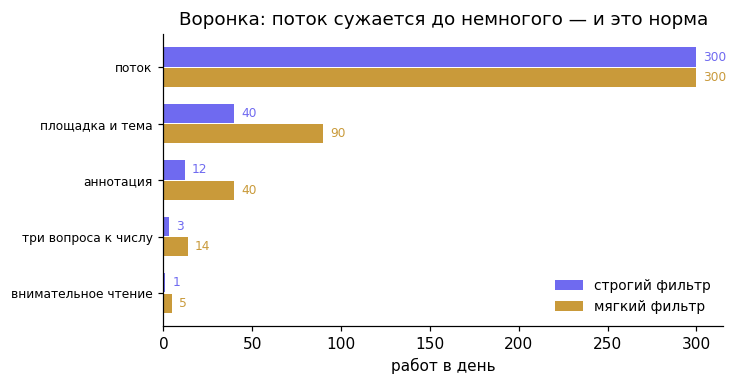

In [3]:
fig, ax = plt.subplots(figsize=(6.8, 3.6))
y = np.arange(len(stages))[::-1]
ax.barh(y + 0.18, strict, height=0.34, color=ACCENT, label="строгий фильтр")
ax.barh(y - 0.18, loose,  height=0.34, color=GOLD,  label="мягкий фильтр")
for yi, a, b in zip(y, strict, loose):
    ax.text(a + 4, yi + 0.18, "%.0f" % a, va="center", fontsize=8, color=ACCENT)
    ax.text(b + 4, yi - 0.18, "%.0f" % b, va="center", fontsize=8, color=GOLD)
ax.set_yticks(y); ax.set_yticklabels([s.replace("\n", " ") for s in stages], fontsize=8)
ax.set_xlabel("работ в день"); ax.set_title("Воронка: поток сужается до немногого — и это норма")
ax.legend(frameon=False, fontsize=9, loc="lower right")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

Из трёхсот работ в день строгий фильтр доводит до внимательного чтения около одной, мягкий — несколько. Узкое горло воронки — не потеря: одна работа в день, прочитанная глубоко, — это уже 365 в год. Мягкий фильтр пропускает больше, но, как покажет часть 3, платит за это вниманием на отсев шума.

## 2. Глубина против охвата

Две стратегии при одном бюджете внимания. **Глубина:** `k` работ в неделю, прочитанных до понимания, — высокое удержание. **Охват:** `m ≫ k` работ, пролистанных, — почти нулевое удержание. Смотрим на усвоенное (то, что осталось и понято) за год.

In [4]:
weeks = np.arange(1, 53)
k, ret_deep = 2, 0.9          # глубина: 2 работы в неделю, удержание 0.9
m, ret_shallow = 20, 0.05     # охват: 20 работ в неделю, удержание 0.05

# усвоено за неделю; у глубины лёгкое накопление: фон ускоряет чтение
deep_per_week = k * ret_deep
shallow_per_week = m * ret_shallow
knowledge_deep = np.cumsum(deep_per_week * (1 + 0.015 * np.arange(len(weeks))))  # компаундинг
knowledge_shallow = np.cumsum(np.full(len(weeks), shallow_per_week))            # без накопления

print("прочитано за год: глубина %d, охват %d" % (k * 52, m * 52))
print("усвоено к концу года: глубина %.0f, охват %.0f" % (knowledge_deep[-1], knowledge_shallow[-1]))

прочитано за год: глубина 104, охват 1040
усвоено к концу года: глубина 129, охват 52


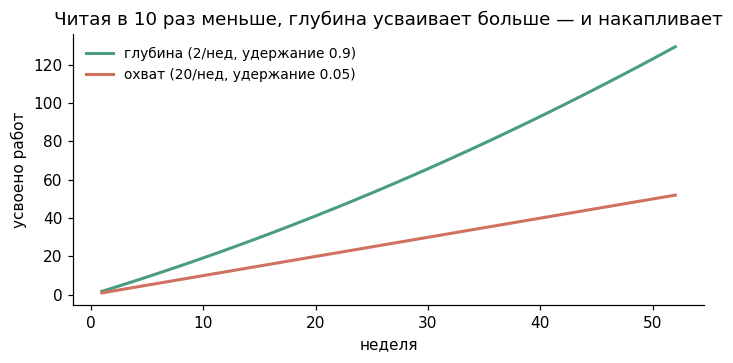

In [5]:
fig, ax = plt.subplots(figsize=(6.6, 3.4))
ax.plot(weeks, knowledge_deep, color=GOOD, lw=2, label="глубина (2/нед, удержание 0.9)")
ax.plot(weeks, knowledge_shallow, color=BAD, lw=2, label="охват (20/нед, удержание 0.05)")
ax.set_xlabel("неделя"); ax.set_ylabel("усвоено работ")
ax.set_title("Читая в 10 раз меньше, глубина усваивает больше — и накапливает")
ax.legend(frameon=False, fontsize=9)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

Охват читает в десять раз больше, но удерживает так мало, что усвоенного меньше, — и оно не накапливается. Глубина читает немного, но каждая проверенная работа остаётся и делает следующую быстрее: кривая идёт вверх с ускорением. Не отстать — это читать глубоко немногое, а не листать много.

## 3. Стоимость мягкого фильтра

Мягкий фильтр пропускает наверх больше работ, но большая часть добавки — шум, который отсеется только после дорогого внимательного чтения. Посчитаем потраченное впустую время как функцию размера потока.

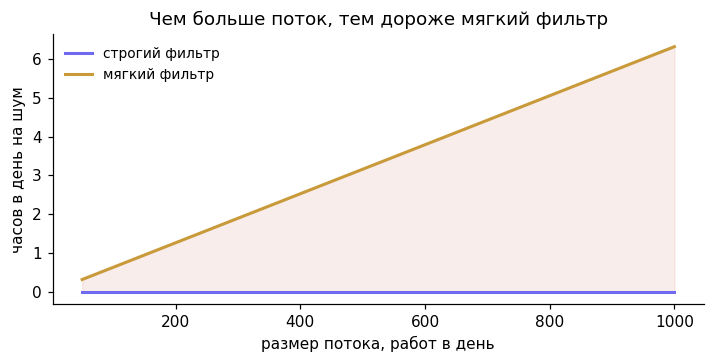

при потоке 300/день на отсев шума уходит: строгий 0.0 ч/день, мягкий 1.9 ч/день


In [6]:
T_READ = 0.5          # часов на одно внимательное чтение
SIGNAL_RATE = 0.004   # доля потока, которая реально стоит глубокого чтения

streams = np.arange(50, 1001, 50)
def wasted_hours(fracs, stream):
    reach = stream * np.prod(fracs[1:])       # доходит до внимательного чтения в день
    signal = stream * SIGNAL_RATE             # из них реально ценных
    noise = max(reach - signal, 0)            # остальное — отсеется после чтения
    return noise * T_READ

waste_strict = np.array([wasted_hours(frac_strict, s) for s in streams])
waste_loose  = np.array([wasted_hours(frac_loose,  s) for s in streams])

fig, ax = plt.subplots(figsize=(6.6, 3.4))
ax.plot(streams, waste_strict, color=ACCENT, lw=2, label="строгий фильтр")
ax.plot(streams, waste_loose,  color=GOLD,  lw=2, label="мягкий фильтр")
ax.fill_between(streams, waste_strict, waste_loose, color=BAD, alpha=0.12)
ax.set_xlabel("размер потока, работ в день"); ax.set_ylabel("часов в день на шум")
ax.set_title("Чем больше поток, тем дороже мягкий фильтр")
ax.legend(frameon=False, fontsize=9)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()
print("при потоке 300/день на отсев шума уходит: строгий %.1f ч/день, мягкий %.1f ч/день" % (
    wasted_hours(frac_strict, 300), wasted_hours(frac_loose, 300)))

Мягкий фильтр стоит внимания, и цена растёт с потоком: чем больше выходит работ, тем дороже пропускать шум наверх, где отсев требует дорогого чтения. Строгий фильтр окупается ровно потому, что отсекает дёшево — по площадке и аннотации, — до того, как вы потратили на работу полчаса.

## Курс пройден

Двадцать семь модулей вели к одному: **область движется через заявки, и ваше преимущество — умение их проверять.** От доверительного интервала в [модуле 1](https://drobyshevdev.github.io/lemma/modules/01-claim-baseline-noise/) до воронки чтения здесь — это один навык: отличать сигнал от шума и не строить на шуме.

Осталась выпускная работа: взять статью, вышедшую после начала вашего обучения, воспроизвести её центральную заявку и сравнить с честной базой. Не пересказать — проверить.